<a href="https://colab.research.google.com/github/Ferrrchu/Challenge-TelecomX-Alura-Latam/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [71]:
import pandas as pd
import requests

In [72]:
from pandas.core.frame import DataFrame
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data =  response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [74]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Diccionario de datos
- Identificación del Cliente
  - customerID: número de identificación único de cada cliente
  - Churn: si el cliente dejó o no la empresa
- Información del Cliente
  - gender: género (masculino y femenino)
  - SeniorCitizen: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
  - Partner: si el cliente tiene o no una pareja
  - Dependents: si el cliente tiene o no dependientes
  - tenure: meses de contrato del cliente
- Servicios de Telefonía
  - PhoneService: suscripción al servicio telefónico
  - MultipleLines: suscripción a más de una línea telefónica
- Servicios de Internet
  - InternetService: suscripción a un proveedor de internet
  - OnlineSecurity: suscripción adicional de seguridad en línea
  - OnlineBackup: suscripción adicional de respaldo en línea
  - DeviceProtection: suscripción adicional de protección del dispositivo
  - TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
  - StreamingTV: suscripción de televisión por cable
  - StreamingMovies: suscripción de streaming de películas
- Información de la Cuenta
  - Contract: tipo de contrato
  - PaperlessBilling: si el cliente prefiere recibir la factura en línea
  - PaymentMethod: forma de pago
  - Charges.Monthly: total de todos los servicios del cliente por mes
  - Charges.Total: total gastado por el cliente

#🔧 Transformación

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

## Verificación


### 1. Verificación de valores unicos:

In [76]:
for col in df.columns:
  print(f'- Valores unicos en la columna {col}: {df[col].nunique()}')
  print(df[col].unique())
  print('-'*50)


- Valores unicos en la columna customerID: 7267
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------------------------------------
- Valores unicos en la columna Churn: 3
['No' 'Yes' '']
--------------------------------------------------
- Valores unicos en la columna customer.gender: 2
['Female' 'Male']
--------------------------------------------------
- Valores unicos en la columna customer.SeniorCitizen: 2
[0 1]
--------------------------------------------------
- Valores unicos en la columna customer.Partner: 2
['Yes' 'No']
--------------------------------------------------
- Valores unicos en la columna customer.Dependents: 2
['Yes' 'No']
--------------------------------------------------
- Valores unicos en la columna customer.tenure: 73
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 

### 2. Verificación de valores duplicados:

In [77]:
print('Cantidad de valores repetidos:', df.duplicated().sum())

Cantidad de valores repetidos: 0


### 3. Verificación de valroes nulos

In [78]:
print('Cantidad de valores nulos: ', df.isna().sum())

Cantidad de valores nulos:  customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


### 4. Valores vacios o en blanco:

In [79]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


## Transformación:

1. Cambiando la columna 'account.Charges.Total' a Float

In [80]:
df['account.Charges.Total'] = df['account.Charges.Total'].apply(pd.to_numeric, errors='coerce')
print(df['account.Charges.Total'].dtype)

float64


In [81]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [82]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


2. Eliminar valores vacios en  Churn

In [83]:
df = df[df['Churn'].str.strip() != '']
print('Numero de filas despues de eliminar los valores vacios: ', len(df))

Numero de filas despues de eliminar los valores vacios:  7043


In [84]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [85]:
df = df.dropna(subset=['account.Charges.Total'])
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


### Desarrollos opcionales:

1. Crear una nueva columna con los valores diarios de 'account.Charges.Monthly'

In [87]:
df['cuentas_diarias'] = df['account.Charges.Monthly'] / 30
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


2. Renombrar columnas

In [88]:
columnas = {                                                        # Diccionario con los nuevos nombres de las columnas.
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tiene +60',
    'customer.Partner': 'posee_pareja',
    'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= columnas)
df

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


3. Traducción valores de las columnas

In [92]:
df['Churn'] = df['Churn'].replace({'Yes': 'Si', 'No': 'No'})
df['genero'] = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df['tiene +60'] = df['tiene +60'].replace({1: 'Si', 0: 'No'})
df['posee_pareja'] = df['posee_pareja'].replace({'Yes': 'Si', 'No': 'No'})
df['posee_dependientes'] = df['posee_dependientes'].replace({'Yes': 'Si', 'No': 'No'})
df['servicio_telefono'] = df['servicio_telefono'].replace({'Yes': 'Si', 'No': 'No'})
df['multiples_lineas'] = df['multiples_lineas'].replace({'Yes': 'Si', 'No': 'No', 'No phone service': 'Sin servicio de telefono'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensual', 'Two year': 'Bienal'})
df['factura_digital'] = df['factura_digital'].replace({'Yes': 'Si', 'No': 'No'})

df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Yes,Yes,No,Anual,Si,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Yes,Mensual,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,No,No,No,4,Si,No,Fiber optic,...,Yes,No,No,No,Mensual,Si,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Si,Masculino,Si,Si,No,13,Si,No,Fiber optic,...,Yes,No,Yes,Yes,Mensual,Si,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,Si,Si,No,3,Si,No,Fiber optic,...,No,Yes,Yes,No,Mensual,Si,Mailed check,83.9,267.40,2.796667


In [93]:
columnas_a_traducir = ['seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas']
mapeo = {'No': 'No', 'Yes': 'Sí', 'No internet service': 'Sin servicio de internet'}

for col in columnas_a_traducir:
    df[col] = df[col].replace(mapeo)

df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Sí,Sí,No,Anual,Si,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Sí,Mensual,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,No,No,No,4,Si,No,Fiber optic,...,Sí,No,No,No,Mensual,Si,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Si,Masculino,Si,Si,No,13,Si,No,Fiber optic,...,Sí,No,Sí,Sí,Mensual,Si,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,Si,Si,No,3,Si,No,Fiber optic,...,No,Sí,Sí,No,Mensual,Si,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

1. Analisis descriptivo:

In [94]:
df.describe()

,tiempo_contrato,valor_mensal,total_cobrado,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.587500,401.450000,1.186250
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.862500,3794.737500,2.995417
max,72.000000,118.750000,8684.800000,3.958333


2. Distribución de evasión:

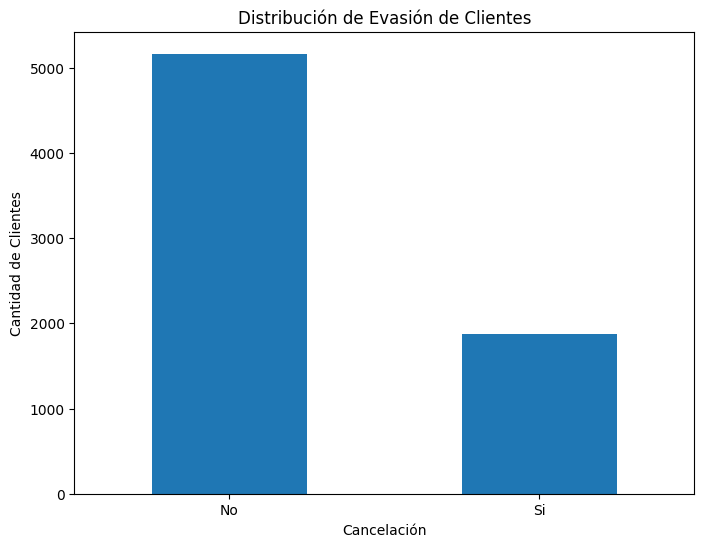

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
df['Churn'].value_counts().plot(kind='bar')
plt.title('Distribución de Evasión de Clientes')
plt.xlabel('Cancelación')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.show()

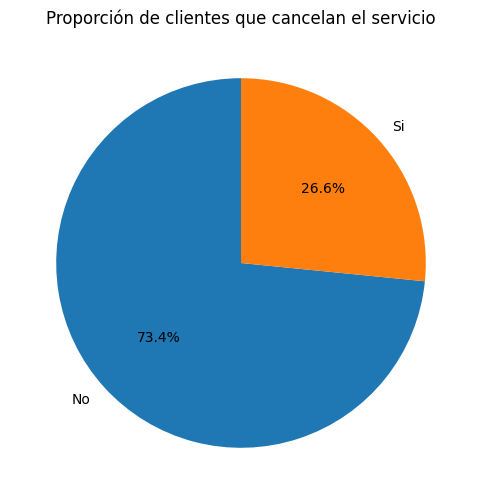

In [102]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Proporción de clientes que cancelan el servicio')
plt.ylabel('')
plt.show()

El gráfico muestra que el 73,4% de los clientes no canceló el servicio, mientras que el 26,6% sí lo hizo. A simple vista, la mayoría de los clientes permanece en la empresa, lo cual es un dato positivo. Sin embargo, el porcentaje de cancelación no es menor: aproximadamente 1 de cada 4 clientes abandona el servicio.

3. Recuento de evasión por variables categóricas

In [104]:
import plotly.express as px

In [115]:
import seaborn as sns

def grafico_churn_categorica(df, columna):
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=columna, hue='Churn')
    plt.title(f'Churn según {columna}')
    plt.xlabel(columna)
    plt.ylabel('Cantidad de clientes')
    plt.xticks(rotation=45)
    plt.show()

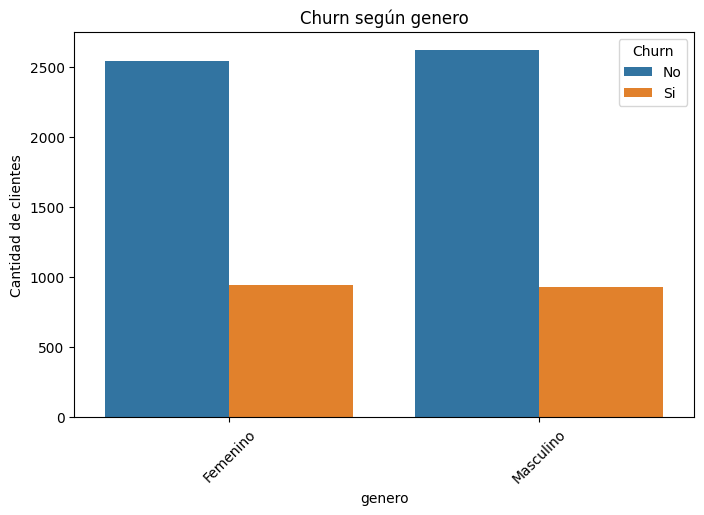

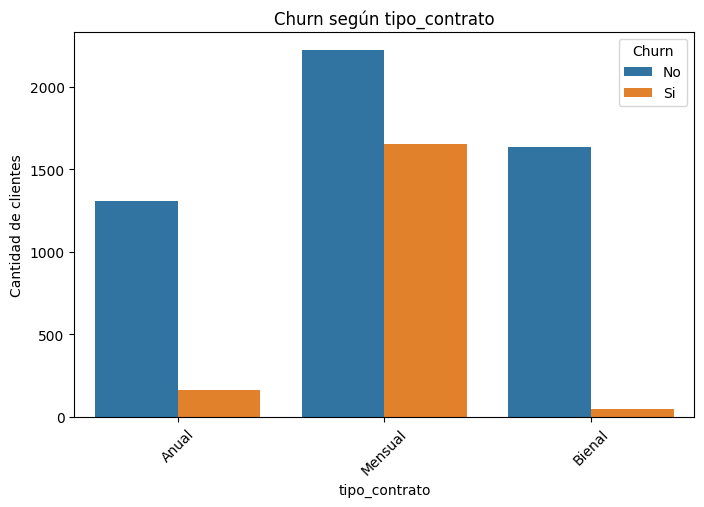

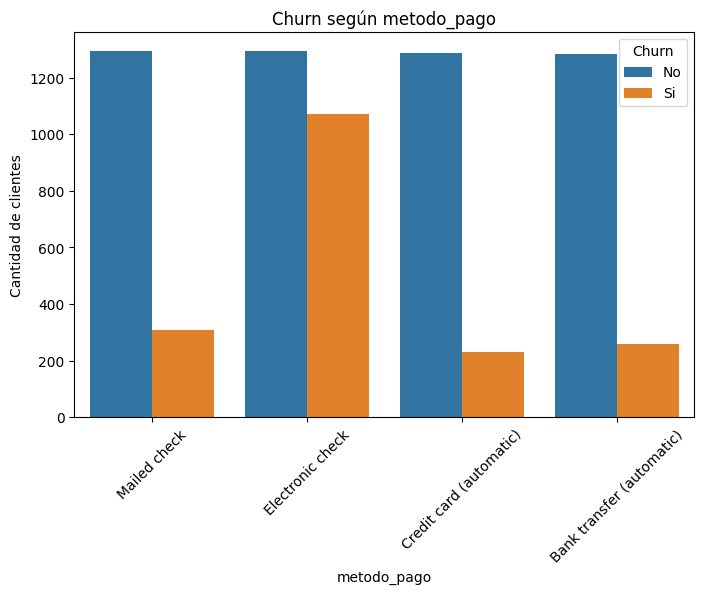

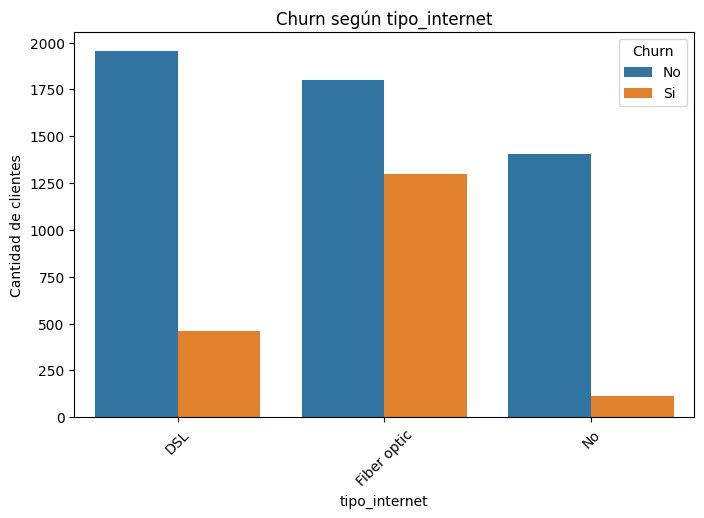

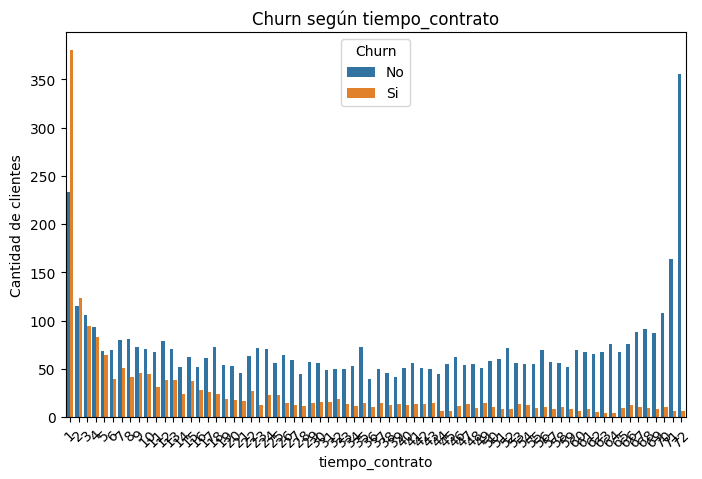

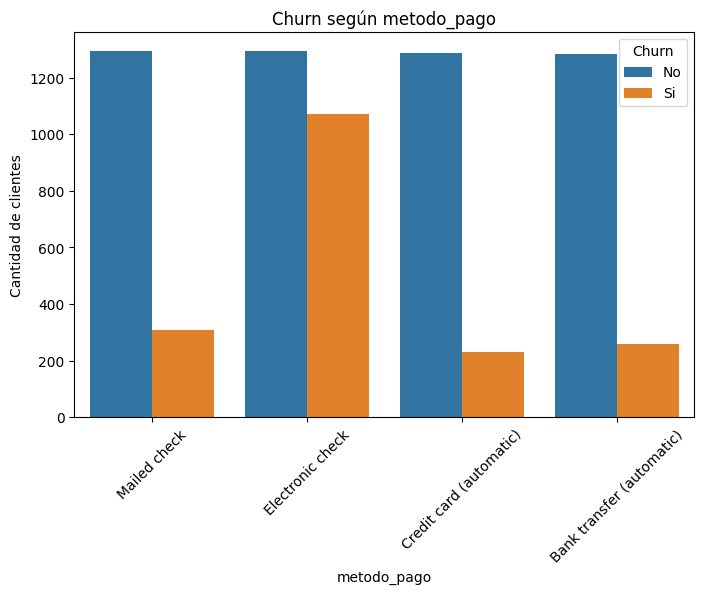

In [119]:
grafico_churn_categorica(df, 'genero')
grafico_churn_categorica(df, 'tipo_contrato')
grafico_churn_categorica(df, 'metodo_pago')
grafico_churn_categorica(df, 'tipo_internet')
grafico_churn_categorica(df, 'tiempo_contrato')
grafico_churn_categorica(df, 'metodo_pago')

4. Conteo de evasión por variables numéricas

In [123]:
def boxplot_churn(df, columna):
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='Churn', y=columna)
    plt.title(f'Distribución de {columna} según churn')
    plt.xlabel('Churn')
    plt.ylabel(columna)
    plt.show()

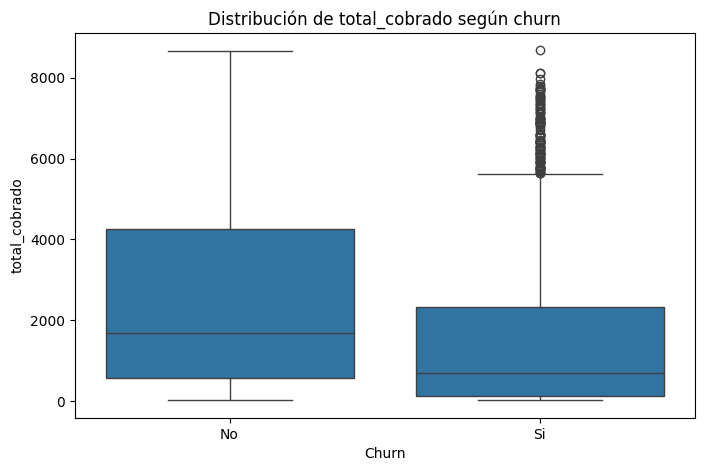

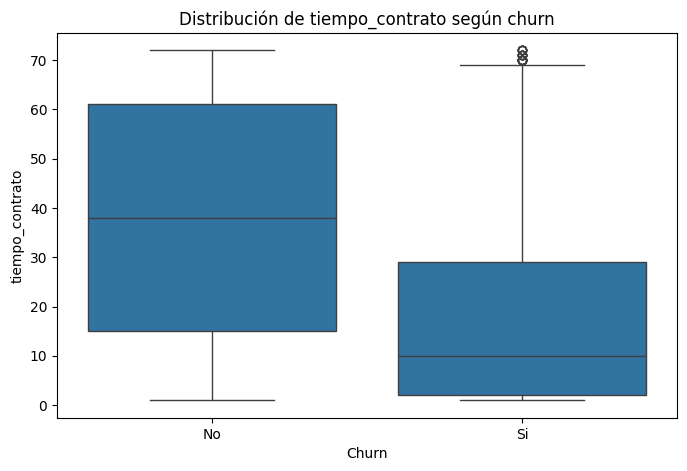

In [124]:
boxplot_churn(df, 'total_cobrado')
boxplot_churn(df, 'tiempo_contrato')

In [125]:
def histograma_churn(df, columna):
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x=columna, hue='Churn', kde=True, element='step')
    plt.title(f'Distribución de {columna} según churn')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.show()

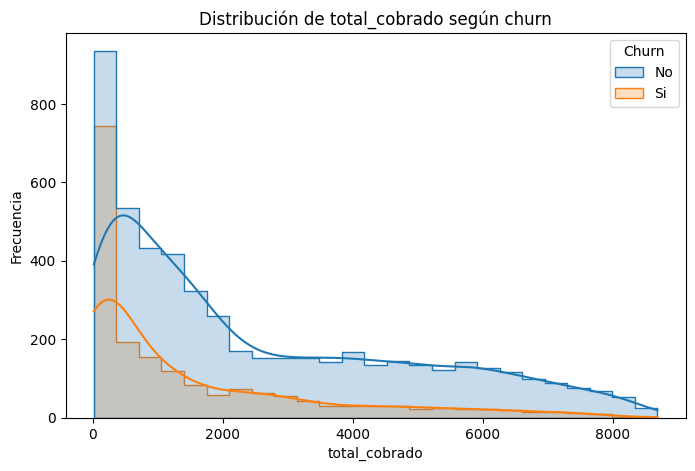

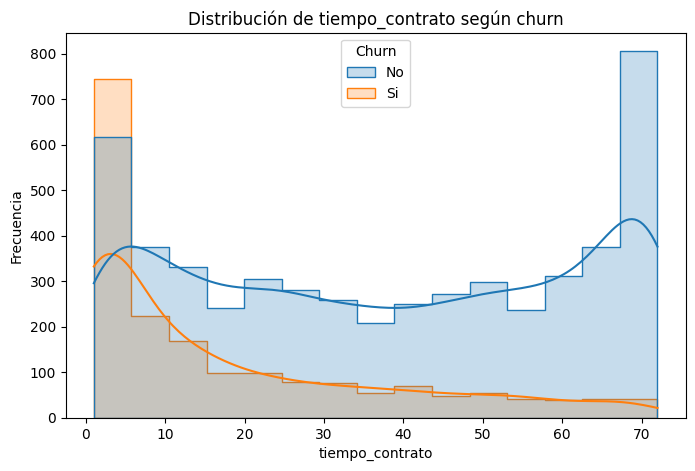

In [126]:
histograma_churn(df, 'total_cobrado')
histograma_churn(df, 'tiempo_contrato')

- La antigüedad parece ser un factor muy importante. Los clientes nuevos tienen más probabilidad de irse, mientras que los que logran permanecer más tiempo tienden a quedarse.
- El total_cobrado no parece ser por sí solo la causa del churn, sino más bien una consecuencia del tiempo de permanencia: quien se va temprano, naturalmente habrá pagado menos en total.

#📄Informe final


## Introducción

El objetivo de este análisis fue estudiar la evasión de clientes (**Churn**) en Telecom X, identificando qué características están asociadas con una mayor probabilidad de cancelación del servicio.

A partir de los datos disponibles, se buscó detectar patrones de comportamiento entre los clientes que permanecen en la compañía y aquellos que cancelan. Para ello, se realizó un proceso de limpieza y tratamiento de datos, seguido de un análisis exploratorio con visualizaciones que permitieron comparar la evasión según variables categóricas y numéricas.

## Limpieza y tratamiento de datos

La primera etapa consistió en la importación de los datos desde la API en formato JSON y su posterior normalización, con el fin de transformar la estructura anidada en una tabla adecuada para el análisis. Luego, se realizó una revisión general de columnas, tipos de datos y valores únicos para comprender mejor la estructura del dataset.

Entre los principales pasos de limpieza y transformación se destacaron:

- Normalización del archivo JSON para convertirlo en un `DataFrame`.
- Renombrado de columnas a nombres más claros y en español, facilitando la interpretación del análisis.
- Conversión de variables categóricas binarias, como por ejemplo valores `0` y `1`, a etiquetas más comprensibles como `Si` y `No`.
- Transformación de columnas numéricas, especialmente `total_cobrado`, utilizando conversión a tipo numérico,
- Verificación de datos faltantes y revisión de tipos de datos para asegurar que las variables estuvieran correctamente preparadas antes de graficar y analizar.


## Análisis exploratorio de datos

### Distribución general de churn

El análisis inicial de la variable objetivo mostró que aproximadamente el **73,4%** de los clientes permanecen en la empresa, mientras que el **26,6%** cancelaron el servicio. Aunque la mayoría continúa siendo cliente, esta proporción de evasión no es menor, ya que implica que aproximadamente **1 de cada 4 clientes** abandona la compañía.

Este resultado justificó profundizar el análisis para identificar qué factores pueden estar influyendo en esa cancelación.

### Análisis de variables categóricas

Luego se exploró cómo se distribuye el churn según distintas variables categóricas, como género, condición de adulto mayor, tipo de contrato, método de pago y servicios contratados.

A partir de los gráficos realizados, se observó que algunas variables presentan patrones más marcados que otras:

- El género no parece mostrar una diferencia fuerte en la evasión, por lo que no se perfila como un factor determinante por sí solo.
- Variables como tener pareja o tener dependientes suelen asociarse con una menor proporción de cancelación, lo que sugiere que los clientes con vínculos familiares o mayor estabilidad tienden a permanecer más tiempo.
- La variable adulto mayor puede presentar una diferencia relevante, indicando que ciertos perfiles demográficos requieren mayor atención.
- El tipo de contrato aparece como uno de los factores más importantes: los clientes con contratos mensuales muestran una tendencia mayor a cancelar, mientras que los contratos de uno o dos años presentan más permanencia.
- El método de pago también muestra diferencias, especialmente en aquellos métodos más vinculados a pagos automáticos o electrónicos.
- En cuanto a los servicios de internet y complementarios, variables como tipo de internet, seguridad online, soporte técnico y protección del dispositivo ayudan a identificar perfiles con distinta propensión a la cancelación.

En conjunto, este análisis permitió detectar que la cancelación no se distribuye de forma uniforme entre todos los clientes, sino que ciertos grupos concentran un riesgo mayor de evasión.

### Análisis de variables numéricas

También se estudió la relación entre churn y variables numéricas, especialmente tiempo_contrato, valor_mensal y total_cobrado.

Los gráficos de distribución e histogramas permitieron observar tendencias importantes:

- Los clientes que cancelan suelen concentrarse en valores más bajos de tiempo_contrato, lo que indica que la evasión es más frecuente en los primeros meses de relación con la empresa.
- En total_cobrado, los clientes que no cancelan suelen acumular valores más altos, lo cual es esperable porque llevan más tiempo activos.
- En valor_mensal, es habitual observar que los clientes con churn se concentran en ciertos rangos de cobro mensual, lo que puede sugerir una percepción de bajo valor frente al precio pagado.

Estos resultados muestran que la evasión no solo depende del perfil del cliente o del servicio contratado, sino también de variables económicas y de permanencia.


## Conclusiones e insights

A partir del análisis realizado, se concluye que la evasión de clientes en Telecom X es un problema relevante y que no ocurre de manera aleatoria. Existen patrones claros que permiten identificar perfiles con mayor riesgo de cancelación.

Los principales hallazgos fueron:

- La tasa de churn es significativa, con un 26,6% de clientes que cancelaron.
- El tipo de contrato es una de las variables más influyentes, con mayor evasión en contratos de corto plazo.
- El tiempo de permanencia es muy importante, los clientes más nuevos muestran mayor probabilidad de abandono.
- Algunas variables de perfil, como tener pareja, tener dependientes o pertenecer a determinados grupos demográficos, muestran diferencias en la tasa de churn.
- Métodos de pago y combinaciones de servicios parecen estar asociados a una mayor cancelación.

## Recomendaciones


1. **Fortalecer la retención en los primeros meses del cliente**, ya que la cancelación parece concentrarse especialmente en etapas tempranas de la relación comercial.
2. **Incentivar contratos de mayor duración**, ofreciendo beneficios, descuentos o condiciones preferenciales para clientes que migren desde contratos mensuales a planes anuales.
3. **Revisar los métodos de pago asociados a mayor cancelación**, buscando simplificar la experiencia del cliente y reducir fricciones en la facturación.
4. **Agregar valor a los servicios complementarios**, como soporte técnico, seguridad online o protección de dispositivos, para reforzar la percepción de beneficio del servicio contratado.
5. **Profundizar el análisis con modelos predictivos**, ya que este estudio exploratorio permite identificar patrones, pero un modelo de clasificación podría anticipar qué clientes tienen mayor riesgo de cancelar.
